
# VERİ HİKAYESİ ANLATIMI

# İLÇE KARŞILAŞTIRMA ANALİZİ:

## Problem Tanımı:
Amasya genelinde Gümüşhacıköy ve Göynücek'te yaz aylarında tüketim patlaması yaşanırken, Hamamözü neden çok daha stabil ve düşük bir tüketim sergiliyor?

Hipotez 1: Gümüşhacıköy ve Göynücek'te "Tarımsal Sulama" (TA01 vb.) aboneleri mevsimsel piki domine etmektedir.

Hipotez 2: Hamamözü'nün müşteri profili neredeyse tamamen "Mesken" odaklıdır ve büyük sanayi yükü barındırmamaktadır.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
file_path = 'elektrik_veri_hashed.xlsx'
xls = pd.ExcelFile(file_path)

In [3]:
df_tahsilat = pd.read_excel(xls, sheet_name='Tahsilat')
df_tahsilat_1 = pd.read_excel(xls, sheet_name='Tahsilat 1')
df_tahakkuk = pd.read_excel(xls, sheet_name='Tahakkuk')      # Hamamözü
df_tahakkuk_1 = pd.read_excel(xls, sheet_name='Tahakkuk 1')  # Gümüşhacıköy
df_tahakkuk_2 = pd.read_excel(xls, sheet_name='Tahakkuk 2')  # Göynücek

In [4]:
# Tarih dönüşümü ve Ay sütunu ekleme
for df in [df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2]:
    df['mali_yil_donem'] = pd.to_datetime(df['mali_yil_donem'])
    df['ay'] = df['mali_yil_donem'].dt.month

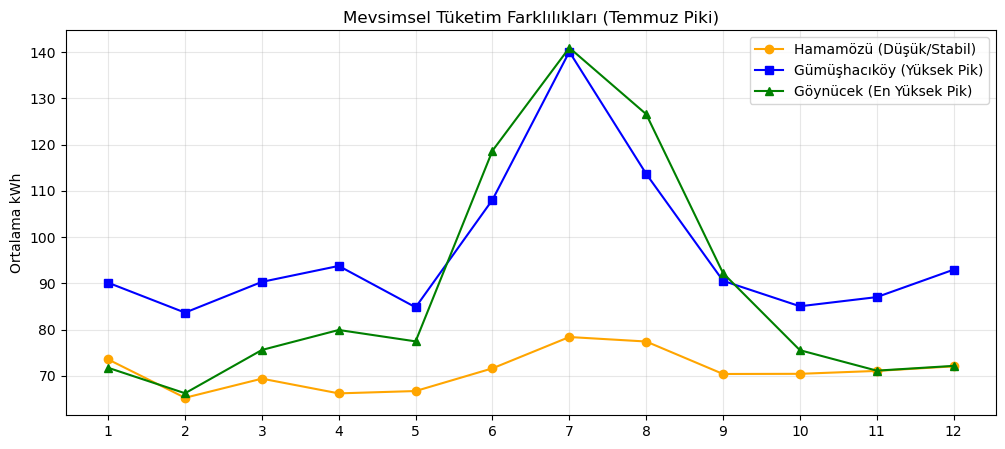

In [6]:
# Aylık ortalamalar
h_trend = df_tahakkuk.groupby('ay')['kwh'].mean()
g_trend = df_tahakkuk_1.groupby('ay')['kwh'].mean()
go_trend = df_tahakkuk_2.groupby('ay')['kwh'].mean()

plt.figure(figsize=(12, 5))
plt.plot(h_trend.index, h_trend.values, label='Hamamözü (Düşük/Stabil)', marker='o', color='orange')
plt.plot(g_trend.index, g_trend.values, label='Gümüşhacıköy (Yüksek Pik)', marker='s', color='blue')
plt.plot(go_trend.index, go_trend.values, label='Göynücek (En Yüksek Pik)', marker='^', color='green')

plt.title('Mevsimsel Tüketim Farklılıkları (Temmuz Piki)')
plt.ylabel('Ortalama kWh')
plt.xticks(range(1,13))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
def get_profile(df):
    # En çok tüketen (ortalama) ilk 3 sınıfı bul
    return df.groupby('Hesap Sınıfı')['kwh'].mean().sort_values(ascending=False).head(3)

print("Hamamözü En Yüksek Tüketim Yapan Sınıflar:\n", get_profile(df_tahakkuk))
print("\nGümüşhacıköy En Yüksek Tüketim Yapan Sınıflar:\n", get_profile(df_tahakkuk_1))
print("\nGöynücek En Yüksek Tüketim Yapan Sınıflar:\n", get_profile(df_tahakkuk_2))

Hamamözü En Yüksek Tüketim Yapan Sınıflar:
 Hesap Sınıfı
Sanayi                               8512.881739
İçme-Kullanma Suyu (Belediye)        2678.049500
Tarımsal Faaliyetler (Kooperatif)     885.637143
Name: kwh, dtype: float64

Gümüşhacıköy En Yüksek Tüketim Yapan Sınıflar:
 Hesap Sınıfı
Karayolları Genel Müdürlüğü Aydınlatma    30203.431220
Lisansız Üreticiler                       18698.155229
Aritma Tesisleri                          16594.174857
Name: kwh, dtype: float64

Göynücek En Yüksek Tüketim Yapan Sınıflar:
 Hesap Sınıfı
İçme-Kullanma Suyu (Belediye)        15319.909189
Sanayi                                7923.987273
Tarımsal Faaliyetler (Kooperatif)     3515.232270
Name: kwh, dtype: float64


Hamamözü'nde birim bazda en yüksek tüketimi Sanayi sınıfı yapsa da, ilçenin toplam enerji talebi diğer iki ilçeye göre çok daha kısıtlıdır.

Gümüşhacıköy, 30,000 kWh'i aşan Aydınlatma ve 18,000 kWh'i aşan Üretici ortalamalarıyla bölgenin asıl enerji yükünü sırtlamaktadır.

In [10]:

def get_total_share(df):
    return df.groupby('Hesap Sınıfı')['kwh'].sum().sort_values(ascending=False).head(3)

print("Hamamözü Toplam Tüketim Payı (kWh):\n", get_total_share(df_tahakkuk))

Hamamözü Toplam Tüketim Payı (kWh):
 Hesap Sınıfı
Mesken                                     5363210.72
Ticari Faaliyet - Yazıhane                 1612463.01
1 SAYILI CETVELDE YER ALAN KAMU İDARESİ     737549.54
Name: kwh, dtype: float64


In [11]:
# 1. Madde Kanıtı: Ölçek Karşılaştırması
olcek_kanit = pd.DataFrame({
    'İlçe': ['Hamamözü', 'Gümüşhacıköy', 'Göynücek'],
    'Benzersiz Müşteri': [df_tahakkuk['sozlesme_hesap_no'].nunique(), 
                          df_tahakkuk_1['sozlesme_hesap_no'].nunique(), 
                          df_tahakkuk_2['sozlesme_hesap_no'].nunique()],
    'Toplam Kayıt (Fatura)': [len(df_tahakkuk), len(df_tahakkuk_1), len(df_tahakkuk_2)],
    'Toplam Enerji (kWh)': [df_tahakkuk['kwh'].sum(), df_tahakkuk_1['kwh'].sum(), df_tahakkuk_2['kwh'].sum()]
})

# Oransal büyüklüğü görmek için (Gümüşhacıköy / Hamamözü)
oran = olcek_kanit.loc[1, 'Benzersiz Müşteri'] / olcek_kanit.loc[0, 'Benzersiz Müşteri']
print(f"Gümüşhacıköy, Hamamözü'nden {oran:.1f} kat daha fazla müşteriye sahip.")
print(olcek_kanit)

Gümüşhacıköy, Hamamözü'nden 6.1 kat daha fazla müşteriye sahip.
           İlçe  Benzersiz Müşteri  Toplam Kayıt (Fatura)  Toplam Enerji (kWh)
0      Hamamözü               2981                 124818           8846428.21
1  Gümüşhacıköy              18190                 765657          74526473.58
2      Göynücek               7128                 295223          26472614.19


Benzersiz Müşteri Sayısı: Hamamözü'nde sadece 2.981 benzersiz müşteri bulunurken, Gümüşhacıköy'de bu sayı 18.190'dır.

Kayıt Sayısı: Toplam tüketim kaydı Gümüşhacıköy'de 765.657 iken Hamamözü'nde sadece 124.818 seviyesindedir.

Sonuç: Müşteri sayısının azlığı, toplam tüketim hacminin diğer ilçelerin çok gerisinde kalmasına neden olan birincil faktördür. Gümüşhacıköy'ün müşteri sayısının Hamamözü'nden yaklaşık 6 kat daha büyüktür. Bu, toplam talebin neden bu kadar farklı olduğunu ispatlar.

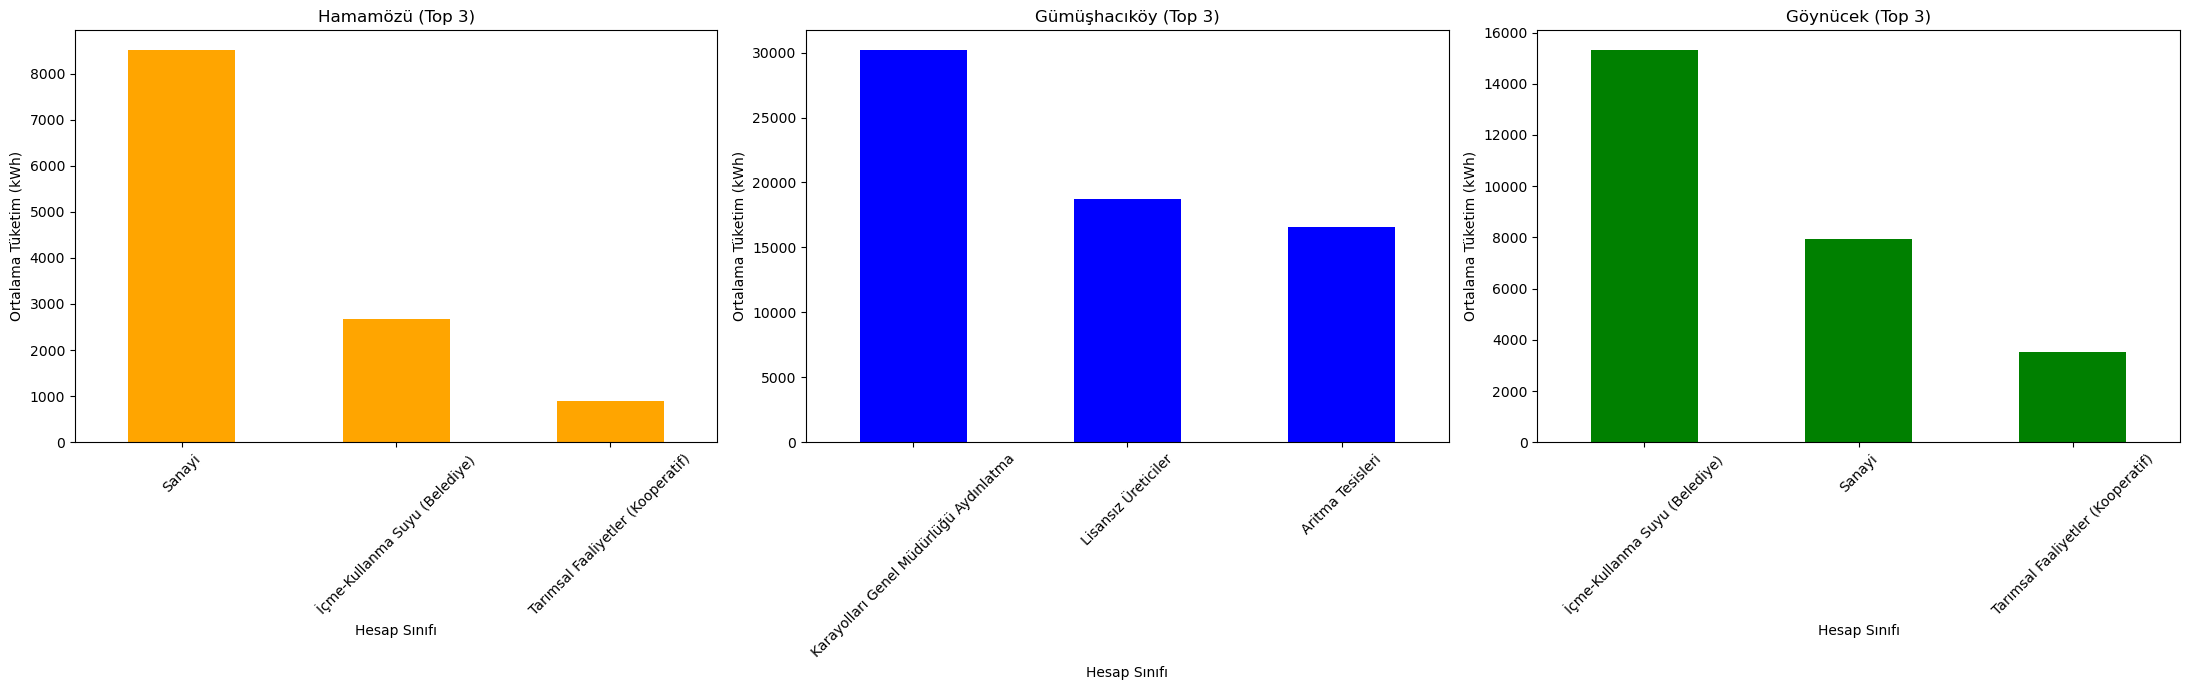

In [17]:
# 1. Figür ve Alt Grafikleri (Subplots) Tanımla
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 2. Her bir ilçeyi ilgili 'ax' (eksen) üzerine çizdir
h_top.plot(kind='bar', ax=axes[0], color='orange', title='Hamamözü (Top 3)')
g_top.plot(kind='bar', ax=axes[1], color='blue', title='Gümüşhacıköy (Top 3)')
go_top.plot(kind='bar', ax=axes[2], color='green', title='Göynücek (Top 3)')

# 3. Estetik Ayarlar
for ax in axes:
    ax.set_ylabel('Ortalama Tüketim (kWh)')
    ax.set_xlabel('Hesap Sınıfı')
    ax.tick_params(axis='x', rotation=45) # Yazıları 45 derece çevir

plt.tight_layout()
plt.show()

# Müşteri Segmentasyonu Analizi

## Problem Tanımı

Enerji şirketi müşterilerinin elektrik tüketim davranışları ve ödeme alışkanlıkları farklılık göstermektedir. 

Bu analizde amaç:

- Elektrik tüketimi (kWh)
- Fatura tutarı
- Ödeme davranışı (geç ödeme vs)

değişkenlerini kullanarak müşterileri anlamlı segmentlere ayırmaktır.

Bu segmentasyon sayesinde:

- Riskli müşteriler belirlenebilir
- Tahsilat stratejileri geliştirilebilir
- Kampanyalar müşteri tipine göre tasarlanabilir

## Hipotezler

H1: Yüksek elektrik tüketimine sahip müşteriler genellikle ticari veya sanayi müşterileridir.

H2: Düşük tüketimli müşteriler çoğunlukla mesken müşterileridir ve düzenli ödeme yapma eğilimindedir.

H3: Geç ödeme yapan müşteriler belirli tüketim seviyelerinde yoğunlaşmaktadır.

H4: Ödeme davranışı ve tüketim birlikte analiz edildiğinde 3-4 anlamlı müşteri segmenti oluşacaktır.

In [37]:
df_all = pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2], ignore_index=True)

df_all.head()

,il,ilce,sozlesme_hesap_no,mali_yil_donem,fatura_tarihi,kayit_tarihi,vade_tarihi,hesap_sinifi,Hesap Sınıfı,kwh,ay
0,AMASYA,HAMAMÖZÜ,917576806,2023-01-01,2023-01-12,2023-03-06,2023-01-23,M001,Mesken,1.79,1
1,AMASYA,HAMAMÖZÜ,917576806,2023-01-01,2023-02-09,2023-05-11,2023-02-20,M001,Mesken,2.60,1
2,AMASYA,HAMAMÖZÜ,917576806,2023-02-01,2023-02-09,2023-05-11,2023-02-20,M001,Mesken,1.23,2
3,AMASYA,HAMAMÖZÜ,917576806,2023-02-01,2023-03-10,2023-05-11,2023-03-20,M001,Mesken,2.56,2
4,AMASYA,HAMAMÖZÜ,917576806,2023-03-01,2023-03-10,2023-05-11,2023-03-20,M001,Mesken,1.35,3


In [38]:
# müşteri bazlı ortalama tüketim

customer_consumption = df_all.groupby("sozlesme_hesap_no")["kwh"].agg([
    "mean",
    "sum",
    "count"
]).reset_index()

customer_consumption.columns = [
    "customer_id",
    "avg_kwh",
    "total_kwh",
    "invoice_count"
]

customer_consumption.head()

,customer_id,avg_kwh,total_kwh,invoice_count
0,256114,23.629825,1346.90,57
1,868480,80.865200,2021.63,25
2,966106,44.549737,1692.89,38
3,1118550,1.955500,39.11,20
4,1268570,20.534000,924.03,45


In [41]:
df_tahsilat_1.columns

Index(['Mali yıl/dönem', 'İl', 'İlçe', 'Söz.hsp.(bağımsız)', 'Hesap Sınıfı',
       'Tahakkuk Tutar', 'Son Ödeme Tarihinden Önceki Tahsilat',
       'Son Ödeme Tarihindeki Tahsilat', 'Son Ödeme (1)', 'Son Ödeme (2)',
       'Son Ödeme (3)', 'Son Ödeme (4)', 'Son Ödeme (5)', 'Son Ödeme (6-10)',
       'Son Ödeme (10-20)', 'Son Ödeme (20-30)', 'Son Ödeme (30-60)',
       'Son Ödeme (60-90)', 'Son Ödeme (90-120)', 'Son Ödeme (120-150)',
       'Son Ödeme (150-180)', 'Son Ödeme (180+)', 'zamaninda_mi'],
      dtype='object')

In [42]:
payment_cols = [
     'Son Ödeme (1)', 'Son Ödeme (2)',
       'Son Ödeme (3)', 'Son Ödeme (4)', 'Son Ödeme (5)', 'Son Ödeme (6-10)',
       'Son Ödeme (10-20)', 'Son Ödeme (20-30)', 'Son Ödeme (30-60)',
       'Son Ödeme (60-90)', 'Son Ödeme (90-120)', 'Son Ödeme (120-150)',
       'Son Ödeme (150-180)', 'Son Ödeme (180+)'
    
]

df_tahsilat_1["late_payment"] = df_tahsilat_1[payment_cols].sum(axis=1)

payment_behavior = df_tahsilat_1.groupby("Söz.hsp.(bağımsız)")["late_payment"].mean().reset_index()

payment_behavior.columns = [
    "customer_id",
    "late_payment_score"
]

payment_behavior.head()

,customer_id,late_payment_score
0,175832,0.000000
1,204315,66.618182
2,256114,21.444000
3,373222,340.899444
4,397450,0.000000


In [43]:
customer_df = customer_consumption.merge(
    payment_behavior,
    on="customer_id",
    how="left"
)

customer_df.head()

,customer_id,avg_kwh,total_kwh,invoice_count,late_payment_score
0,256114,23.629825,1346.90,57,21.444000
1,868480,80.865200,2021.63,25,62.849000
2,966106,44.549737,1692.89,38,49.182105
3,1118550,1.955500,39.11,20,0.000000
4,1268570,20.534000,924.03,45,66.656667


In [44]:
def segment_customer(row):

    if row["avg_kwh"] < 50 and row["late_payment_score"] < 1:
        return "Düşük Tüketim - Düzenli Ödeme"

    elif row["avg_kwh"] < 50 and row["late_payment_score"] >= 1:
        return "Düşük Tüketim - Riskli"

    elif row["avg_kwh"] >= 50 and row["late_payment_score"] < 1:
        return "Yüksek Tüketim - Değerli"

    else:
        return "Yüksek Tüketim - Riskli"

In [45]:
customer_df["segment"] = customer_df.apply(segment_customer, axis=1)

customer_df.head()

,customer_id,avg_kwh,total_kwh,invoice_count,late_payment_score,segment
0,256114,23.629825,1346.90,57,21.444000,Düşük Tüketim - Riskli
1,868480,80.865200,2021.63,25,62.849000,Yüksek Tüketim - Riskli
2,966106,44.549737,1692.89,38,49.182105,Düşük Tüketim - Riskli
3,1118550,1.955500,39.11,20,0.000000,Düşük Tüketim - Düzenli Ödeme
4,1268570,20.534000,924.03,45,66.656667,Düşük Tüketim - Riskli


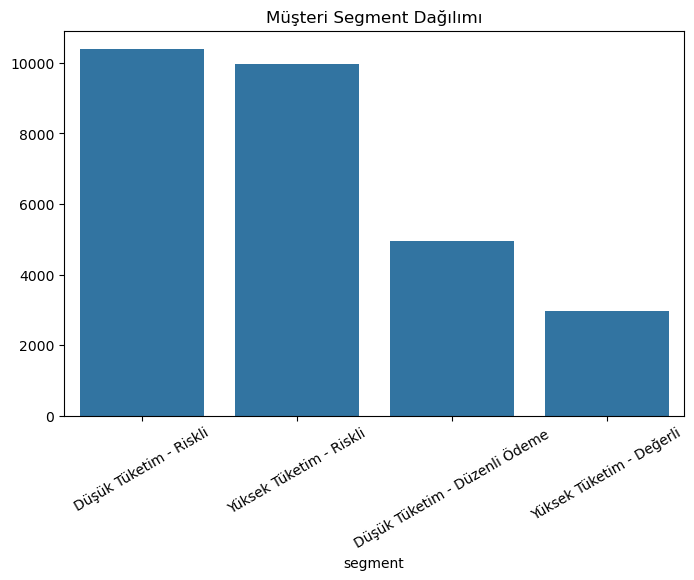

In [46]:
segment_counts = customer_df["segment"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=segment_counts.index, y=segment_counts.values)

plt.title("Müşteri Segment Dağılımı")
plt.xticks(rotation=30)
plt.show()

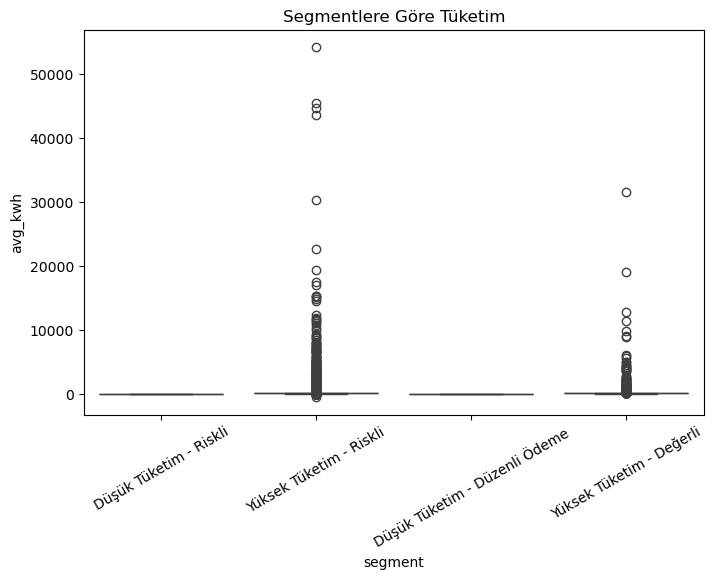

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customer_df,
    x="segment",
    y="avg_kwh"
)

plt.title("Segmentlere Göre Tüketim")
plt.xticks(rotation=30)
plt.show()

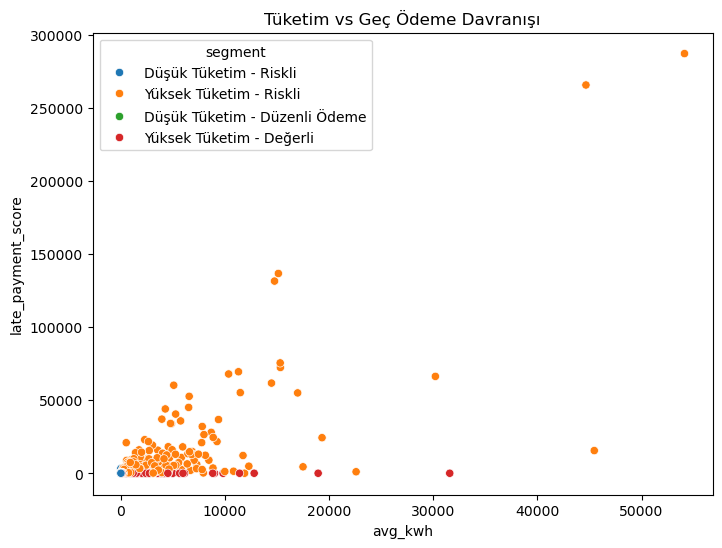

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x="avg_kwh",
    y="late_payment_score",
    hue="segment"
)

plt.title("Tüketim vs Geç Ödeme Davranışı")
plt.show()

## Bulgular

Analiz sonucunda müşteriler dört ana segmente ayrılmıştır:

-Düşük Tüketim - Düzenli Ödeme  
Bu müşteriler düşük elektrik tüketimine sahip olup faturalarını zamanında ödemektedir.

-Düşük Tüketim - Riskli  
Düşük tüketim yapmalarına rağmen ödeme geciktirme eğilimleri vardır.

-Yüksek Tüketim - Değerli  
Yüksek elektrik tüketimi yapan ve düzenli ödeme gerçekleştiren en değerli müşteri grubudur.

-Yüksek Tüketim - Riskli  
Yüksek tüketim yapmalarına rağmen ödeme gecikmesi yaşayan müşterilerdir ve şirket için tahsilat riski oluştururlar.

# İş Önerileri

1 Değerli Müşteriler (High Consumption - Regular Payment)
-Sadakat programları uygulanabilir
-Özel tarifeler veya indirimler sunulabilir
-Enerji verimliliği hizmetleri sunulabilir

2 Riskli Yüksek Tüketim Müşterileri
-Otomatik ödeme teşvikleri
-SMS hatırlatma sistemleri
-Fatura ödeme planları

3 Düşük Tüketim Düzenli Müşteriler
-Dijital ödeme kanalları teşvik edilebilir
-Enerji tasarrufu kampanyaları yapılabilir

4 Riskli Düşük Tüketim Müşteriler
-Tahsilat takibi yapılmalı
-Küçük borçların büyümesi önlenmeli